In [1]:
#import libraries for visualizing data and preprocess the data for train and \\test module packages like pandas,matplotlib,seaborn,scikitlearn,math and warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from math import sqrt
import warnings
warnings.filterwarnings('ignore')


# Load Data


In [2]:
#read the csv or excel file in the choosen location
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel(r"/content/drive/MyDrive/Colab Notebooks/medical_insurance.xlsx")

Mounted at /content/drive


In [3]:
#where the martial status is empty indicates a exception as "martial_status column is not found"

if 'martial_status' in df.columns:
    df = df[['age', 'bmi','gender','smoker', 'martial_status','children','charges']]
else:
    print("'martial_status' column not found in dataset.")
    exit()

In [4]:
df['charges'] = df['charges'].round(0)

#Gender Visualizing Data

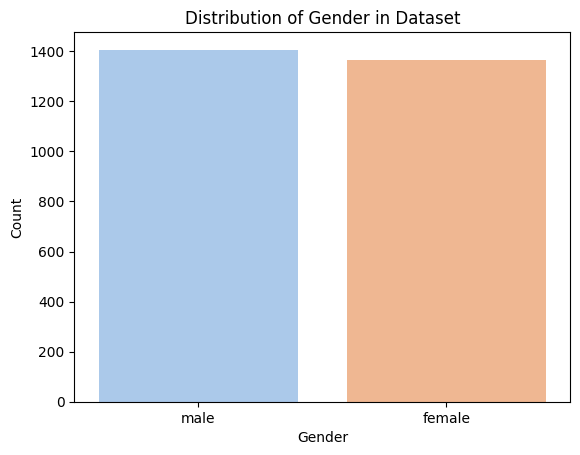

In [5]:
if 'gender' in df.columns:
    gen_counts = df['gender'].value_counts()
    sns.barplot(x=gen_counts.index, y=gen_counts.values, palette='pastel')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.title('Distribution of Gender in Dataset')
    plt.show()
else:
    print("'gender' column not found in the dataset.")

# Martial Status Visualizing

In [6]:
if 'martial_satus' in df.columns:
    mart_c=df['martial_status'].value_counts()
    plt.figure(figsize=(8, 6))
    sns.barplot(x=mart_c.index, y=mart_c.values, palette='pastel')
    plt.xlabel('Martial Status')
    plt.ylabel('Count')
    plt.title('Distribution of Martial Status')
    plt.show()

#Smoker Status

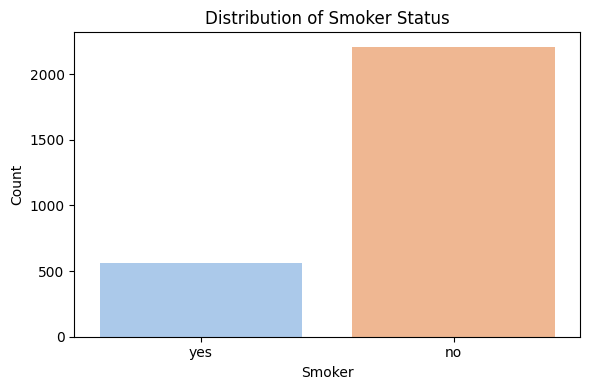

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='smoker', data=df, palette='pastel')
plt.title('Distribution of Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
original_martial_status = df['martial_status'].copy()

In [9]:
le_smoker = LabelEncoder()
df['smoker'] = le_smoker.fit_transform(df['smoker'])

le_martial = LabelEncoder()
df['martial_status'] = le_martial.fit_transform(original_martial_status)

#Train the Data

In [10]:
X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
le_gender = LabelEncoder()
X_train['gender'] = le_gender.fit_transform(X_train['gender'])
X_test['gender'] = le_gender.transform(X_test['gender'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model

In [12]:
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [13]:
y_pred1 = dt_model.predict(X_test)
dt_mse=mean_squared_error(y_test,y_pred1)
dt_rmse = sqrt(dt_mse)
dt_mae = mean_absolute_error(y_test, y_pred1)
dt_r2 = r2_score(y_test, y_pred1)

#PredictedCharge vs ActualCharge

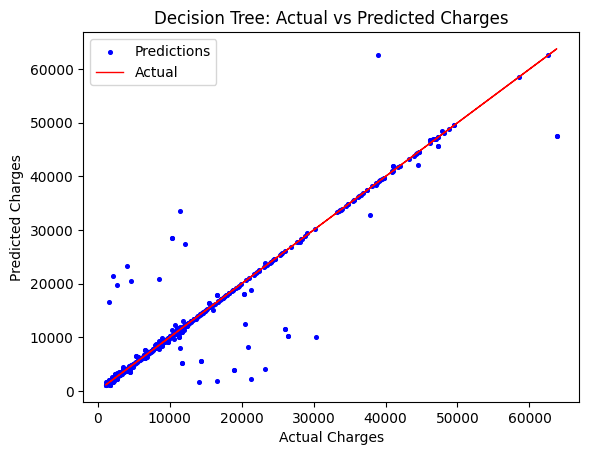

In [14]:
plt.scatter(y_test, y_pred1, color='blue', label='Predictions', s=7)
plt.plot(y_test, y_test, color='red', label='Actual', linewidth=1)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Decision Tree: Actual vs Predicted Charges')
plt.legend()
plt.show()

#Accuracy

In [15]:
print('Decision Tree Model Performance')
print('Mean Squared Error (MSE):', dt_mse)
print('Root Mean Squared Error (RMSE):', dt_rmse)
print('Mean Absolute Error (MAE):', dt_mae)
print('R-squared (R2) Score:', dt_r2)

Decision Tree Model Performance
Mean Squared Error (MSE): 13657437.423423423
Root Mean Squared Error (RMSE): 3695.597032067136
Mean Absolute Error (MAE): 977.9675675675676
R-squared (R2) Score: 0.9110154489744848


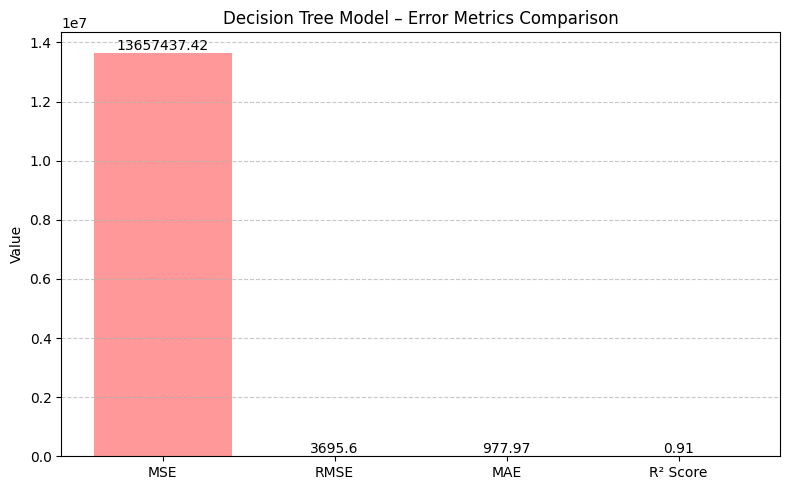

In [16]:
metrics = ['MSE', 'RMSE', 'MAE', 'R² Score']
values = [dt_mse, dt_rmse, dt_mae, dt_r2]
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, round(yval, 2), ha='center', va='bottom', fontsize=10)
plt.title('Decision Tree Model – Error Metrics Comparison')
plt.ylabel('Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#TestingInput

In [ ]:
print("\nEnter patient details to predict insurance charges:")

age = int(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
children = int(input("Enter number of children: "))


Enter patient details to predict insurance charges:
Enter Age: 23
Enter BMI: 23.88876
Enter number of children: 0


#SmokerInput

In [ ]:
smoker_inp = input("Is the patient a smoker? (yes/no): ").strip().lower()
while smoker_inp not in ['yes', 'no']:
    smoker_inp = input("Please enter 'yes' or 'no' for smoker: ").strip().lower()

Is the patient a smoker? (yes/no): yes


# MartialClassInput

In [ ]:
martial_classes = le_martial.classes_
print(f"Available Marital Status Options: {list(martial_classes)}")

martial_inp = input("Enter marital status exactly as in dataset (e.g., married, single, divorced): ").strip().lower()
while martial_inp not in [x.lower() for x in martial_classes]:
    martial_inp = input(f"Please enter a valid marital status {list(martial_classes)}: ").strip().lower()

Available Marital Status Options: ['divorced', 'married', 'single']
Enter marital status exactly as in dataset (e.g., married, single, divorced): married


In [ ]:
matched_class = [x for x in martial_classes if x.lower() == martial_inp][0]

In [ ]:
act_ch = float(input("Enter the actual insurance charge (if known): ₹"))

Enter the actual insurance charge (if known): ₹443277


In [ ]:
gen_inp = input("Enter gender (male/female): ").strip().lower()
while gen_inp not in ['male', 'female']:
    gen_inp = input("Please enter 'male' or 'female' for gender: ").strip().lower()

smo = le_smoker.transform([smoker_inp])[0]
mar = le_martial.transform([matched_class])[0]
gen = le_gender.transform([gen_inp])[0]

inp_data = [[age, bmi, gen, smo, mar, children]]

predi_ch = dt_model.predict(inp_data)[0]

Enter gender (male/female): male


#Bias

In [ ]:
if matched_class.lower() in ['single','married', 'divorced'] and children > 0:
    predi_ch *= 1.10
    print("Adjustment applied: Increased by 10% due to single/divorced/married parent with children.")

In [ ]:
diff = abs(predi_ch - act_ch)

In [ ]:
print("\nInsurance Charge Estimation Report")
print(f" Age: {age}")
print(f" BMI: {bmi}")
print(f" Gender: {gen_inp.capitalize()}")
print(f" Smoker: {smoker_inp.capitalize()}")
print(f" Marital Status: {matched_class.capitalize()}")
print(f" Children: {children}")
print(f" Actual Charge     : ₹{act_ch:,.2f}")
print(f" Predicted Charge  : ₹{predi_ch:,.2f}")
print(f" Difference        : ₹{diff:,.2f}")


Insurance Charge Estimation Report
 Age: 23
 BMI: 23.88876
 Gender: Male
 Smoker: Yes
 Marital Status: Married
 Children: 0
 Actual Charge     : ₹443,277.00
 Predicted Charge  : ₹14,572.00
 Difference        : ₹428,705.00


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Initialize and train RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Make predictions with RandomForestRegressor
y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
# Evaluate RandomForestRegressor
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print('Random Forest Root Mean Squared Error (RMSE):', rf_rmse)
print('Random Forest R-squared (R2) Score:', rf_r2)

Random Forest Root Mean Squared Error (RMSE): 3438.090130037734
Random Forest R-squared (R2) Score: 0.9229841860952136


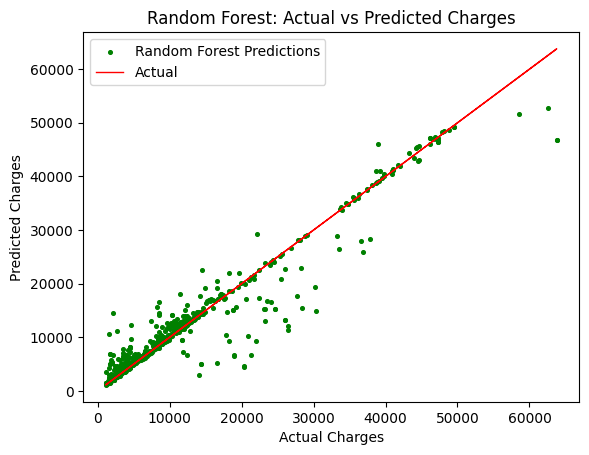

In [ ]:
# Visualize Predictions vs Actual for RandomForestRegressor
plt.scatter(y_test, y_pred_rf, color='green', label='Random Forest Predictions', s=7)
plt.plot(y_test, y_test, color='red', label='Actual', linewidth=1)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Random Forest: Actual vs Predicted Charges')
plt.legend()
plt.show()

In [ ]:
# Collect new input data from the user (assuming the same input process as before)
print("\nEnter patient details to predict insurance charges using RandomForestRegressor:")

age_new = int(input("Enter Age: "))
bmi_new = float(input("Enter BMI: "))
children_new = int(input("Enter number of children: "))

smoker_inp_new = input("Is the patient a smoker? (yes/no): ").strip().lower()
while smoker_inp_new not in ['yes', 'no']:
    smoker_inp_new = input("Please enter 'yes' or 'no' for smoker: ").strip().lower()

# Re-using the previously fitted le_martial to get available martial status options
martial_classes_new = le_martial.classes_
print(f"Available Marital Status Options: {list(martial_classes_new)}")

martial_inp_new = input("Enter marital status exactly as in dataset (e.g., married, single, divorced): ").strip().lower()
while martial_inp_new not in [x.lower() for x in martial_classes_new]:
    martial_inp_new = input(f"Please enter a valid marital status {list(martial_classes_new)}: ").strip().lower()

matched_class_new = [x for x in martial_classes_new if x.lower() == martial_inp_new][0]

gen_inp_new = input("Enter gender (male/female): ").strip().lower()
while gen_inp_new not in ['male', 'female']:
    gen_inp_new = input("Please enter 'male' or 'female' for gender: ").strip().lower()

act_ch_new = float(input("Enter the actual insurance charge (if known): ₹"))

# Preprocess the new input data
smo_new = le_smoker.transform([smoker_inp_new])[0]
mar_new = le_martial.transform([matched_class_new])[0]
gen_new = le_gender.transform([gen_inp_new])[0]

inp_data_new = [[age_new, bmi_new, gen_new, smo_new, mar_new, children_new]]

# Scale the new input data using the *same* scaler fitted on the training data
inp_data_new_scaled = scaler.transform(inp_data_new)

# Predict with the RandomForestRegressor model
predi_ch_rf = rf_model.predict(inp_data_new_scaled)[0]

# Apply the bias adjustment if applicable (using the same logic as before)
if matched_class_new.lower() in ['single','married', 'divorced'] and children_new > 0:
    predi_ch_rf *= 1.10
    print("Adjustment applied: Increased by 10% due to single/divorced/married parent with children.")

# Calculate the difference
diff_rf = abs(predi_ch_rf - act_ch_new)

# Display the results
print("\nRandom Forest Insurance Charge Estimation Report")
print(f" Age: {age_new}")
print(f" BMI: {bmi_new}")
print(f" Gender: {gen_inp_new.capitalize()}")
print(f" Smoker: {smoker_inp_new.capitalize()}")
print(f" Marital Status: {matched_class_new.capitalize()}")
print(f" Children: {children_new}")
print(f" Actual Charge     : ₹{act_ch_new:,.2f}")
print(f" Predicted Charge  : ₹{predi_ch_rf:,.2f}")
print(f" Difference        : ₹{diff_rf:,.2f}")


Enter patient details to predict insurance charges using RandomForestRegressor:
Enter Age: 22
Enter BMI: 22.888884
Enter number of children: 0
Is the patient a smoker? (yes/no): yes
Available Marital Status Options: ['divorced', 'married', 'single']
Enter marital status exactly as in dataset (e.g., married, single, divorced): married
Enter gender (male/female): male
Enter the actual insurance charge (if known): ₹434999

Random Forest Insurance Charge Estimation Report
 Age: 22
 BMI: 22.888884
 Gender: Male
 Smoker: Yes
 Marital Status: Married
 Children: 0
 Actual Charge     : ₹434,999.00
 Predicted Charge  : ₹15,661.61
 Difference        : ₹419,337.39
